In [ ]:
# Load Data
import pandas as pd

# load dataset (sesuaikan nama file kamu)
df = pd.read_csv("House-Price-1.csv")

# lihat 5 data pertama
df.head()

,Unnamed: 0,property_id,status,list_price,price_reduced_amount,last_sold_date,last_sold_price,type,beds,baths,baths_full,lot_sqft,sqft
0,0,2146465328,for_sale,1660000,NaN,2023-05-19,1569000.0,single_family,3.0,4.0,4.0,7488,2120.0
1,1,2053300471,for_sale,2899000,NaN,2021-04-12,2275000.0,single_family,4.0,4.0,1.0,6630,3208.0
2,2,2080355546,for_sale,1995000,NaN,1985-11-15,209500.0,single_family,4.0,4.0,2.0,7523,3202.0
3,3,2822639651,for_sale,749000,NaN,2021-04-28,621000.0,condos,2.0,2.0,2.0,14523,1180.0
4,4,2578787526,for_sale,819000,NaN,2003-08-15,200000.0,single_family,3.0,3.0,2.0,2300,1240.0


In [ ]:
# Cek Struktur Data

# info dataset
df.info()

# statistik dasar
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            133 non-null    int64  
 1   property_id           133 non-null    int64  
 2   status                133 non-null    str    
 3   list_price            133 non-null    int64  
 4   price_reduced_amount  39 non-null     float64
 5   last_sold_date        111 non-null    str    
 6   last_sold_price       111 non-null    float64
 7   type                  133 non-null    str    
 8   beds                  106 non-null    float64
 9   baths                 122 non-null    float64
 10  baths_full            122 non-null    float64
 11  lot_sqft              133 non-null    int64  
 12  sqft                  106 non-null    float64
dtypes: float64(6), int64(4), str(3)
memory usage: 13.6 KB


,Unnamed: 0,property_id,list_price,price_reduced_amount,last_sold_price,beds,baths,baths_full,lot_sqft,sqft
count,133.00000,1.330000e+02,1.330000e+02,39.000000,1.110000e+02,106.000000,122.000000,122.000000,133.000000,106.000000
mean,66.00000,2.817573e+09,2.432427e+06,107147.179487,1.859344e+06,5.622642,5.819672,3.926230,16790.736842,4084.915094
std,38.53786,2.254391e+09,2.438137e+06,93345.056252,4.970827e+06,6.476996,6.219160,3.295798,76497.914225,4430.821870
min,0.00000,1.010819e+09,3.990000e+05,5000.000000,9.090000e+03,0.000000,1.000000,1.000000,1059.000000,635.000000
25%,33.00000,2.031165e+09,1.150000e+06,32000.000000,3.750000e+05,2.250000,2.000000,2.000000,6564.000000,1574.000000
50%,66.00000,2.146838e+09,1.650000e+06,100000.000000,1.000000e+06,4.000000,4.000000,3.000000,7388.000000,2702.000000
75%,99.00000,2.336467e+09,2.700000e+06,141250.000000,1.532000e+06,6.000000,7.000000,5.000000,8603.000000,5177.750000
max,132.00000,9.991792e+09,1.999500e+07,376000.000000,3.722727e+07,50.000000,46.000000,22.000000,875804.000000,31506.000000


In [ ]:
# Data Cleaning: Menghapus Kolom yang Tidak Diperlukan

df = df.drop(columns=["Unnamed: 0", "property_id"])

In [ ]:
# Cek missing value

df.isnull().sum()

status                   0
list_price               0
price_reduced_amount    94
last_sold_date          22
last_sold_price         22
type                     0
beds                    27
baths                   11
baths_full              11
lot_sqft                 0
sqft                    27
dtype: int64

In [ ]:
# Handle missing value

# isi dengan mean untuk numerik
df["sqft"] = df["sqft"].fillna(df["sqft"].mean())

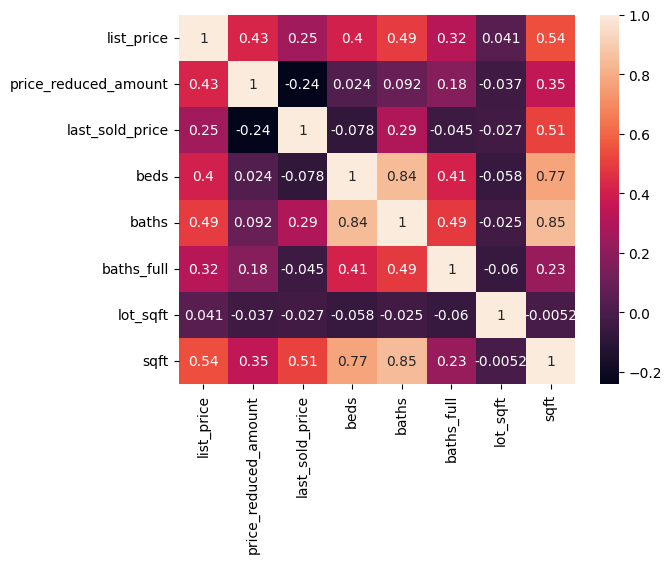

In [9]:
# Korelasi

import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=True)
plt.show()


In [ ]:
# Fokus ke harga

corr["list_price"].sort_values(ascending=False)

list_price              1.000000
sqft                    0.542465
baths                   0.494299
price_reduced_amount    0.425577
beds                    0.403908
baths_full              0.317252
last_sold_price         0.254129
lot_sqft                0.040535
Name: list_price, dtype: float64

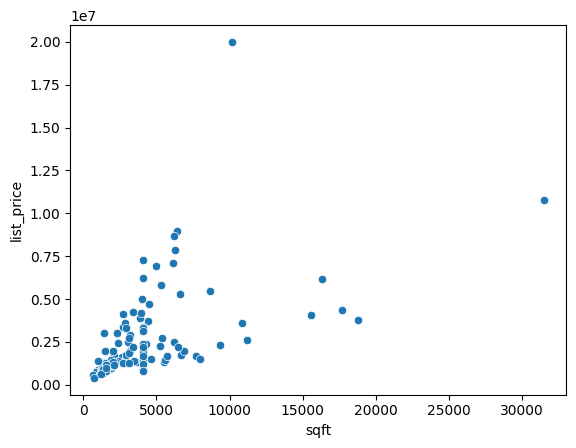

In [ ]:
# Visualisasi hubungan antara sqft dan list_price

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.scatterplot(x=df["sqft"], y=df["list_price"])
plt.show()